In [4]:
# VigilPay | Day 5 — SMOTE (Handle Class Imbalance)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

# Load the saved train/test data from Day 4
X_train = pd.read_csv("../data/X_train.csv")
X_test  = pd.read_csv("../data/X_test.csv")
y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/y_test.csv").squeeze()

print("✅ Data loaded!")
print(f"📐 X_train shape: {X_train.shape}")
print(f"🔍 Fraud in training set BEFORE SMOTE: {y_train.sum()}")
print(f"🔍 Legitimate in training set:         {(y_train==0).sum()}")

✅ Data loaded!
📐 X_train shape: (227845, 30)
🔍 Fraud in training set BEFORE SMOTE: 394
🔍 Legitimate in training set:         227451


In [2]:
import subprocess
subprocess.run(["pip", "install", "imbalanced-learn"])

CompletedProcess(args=['pip', 'install', 'imbalanced-learn'], returncode=0)

In [5]:
# Apply SMOTE to training data ONLY (never on test data!)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("✅ SMOTE applied successfully!")
print(f"\n📊 BEFORE SMOTE:")
print(f"   Fraud:      {y_train.sum()}")
print(f"   Legitimate: {(y_train==0).sum()}")
print(f"\n📊 AFTER SMOTE:")
print(f"   Fraud:      {y_train_smote.sum()}")
print(f"   Legitimate: {(y_train_smote==0).sum()}")
print(f"\n📐 New X_train shape: {X_train_smote.shape}")

✅ SMOTE applied successfully!

📊 BEFORE SMOTE:
   Fraud:      394
   Legitimate: 227451

📊 AFTER SMOTE:
   Fraud:      227451
   Legitimate: 227451

📐 New X_train shape: (454902, 30)


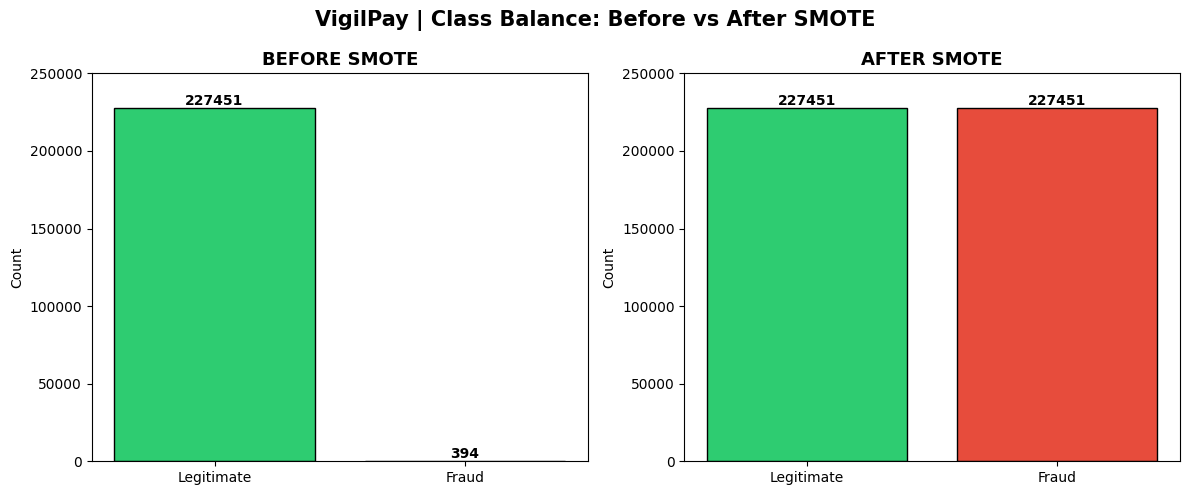

✅ SMOTE comparison chart saved!


In [6]:
# Visualize the balance before and after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before SMOTE
axes[0].bar(['Legitimate', 'Fraud'], 
            [(y_train==0).sum(), y_train.sum()],
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('BEFORE SMOTE', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, 250000)
for i, v in enumerate([(y_train==0).sum(), y_train.sum()]):
    axes[0].text(i, v + 2000, str(v), ha='center', fontweight='bold')

# After SMOTE
axes[1].bar(['Legitimate', 'Fraud'],
            [(y_train_smote==0).sum(), y_train_smote.sum()],
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_title('AFTER SMOTE', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, 250000)
for i, v in enumerate([(y_train_smote==0).sum(), y_train_smote.sum()]):
    axes[1].text(i, v + 2000, str(v), ha='center', fontweight='bold')

plt.suptitle('VigilPay | Class Balance: Before vs After SMOTE', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/smote_comparison.png')
plt.show()
print("✅ SMOTE comparison chart saved!")

In [7]:

X_train_smote_df = pd.DataFrame(X_train_smote, columns=X_train.columns)
y_train_smote_df = pd.Series(y_train_smote, name='Class')

X_train_smote_df.to_csv('../data/X_train_smote.csv', index=False)
y_train_smote_df.to_csv('../data/y_train_smote.csv', index=False)

print("✅ SMOTE data saved!")
print(f"\n📁 Files created:")
print(f"   • X_train_smote.csv — {X_train_smote_df.shape[0]} rows × {X_train_smote_df.shape[1]} features")
print(f"   • y_train_smote.csv — {y_train_smote_df.shape[0]} labels")
print(f"\n🎯 Ready for Day 6 — Model Training!")

✅ SMOTE data saved!

📁 Files created:
   • X_train_smote.csv — 454902 rows × 30 features
   • y_train_smote.csv — 454902 labels

🎯 Ready for Day 6 — Model Training!
